# 0) Starter Code (Run First)

In [1]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

# Question 01: [ Marks 10 ]

Use NumPy arrays from the score and attendance columns. Print both arrays and display:

* Data type
* Number of dimensions
* Shape
* Total number of elements

# Write Answer 01:

In [2]:
import numpy as np

data = np.genfromtxt('school_data.csv', delimiter=',', skip_header=1)

score_array = data[:, 2]
attendance_array = data[:, 3]

array = [("score", score_array), ("attendance", attendance_array)]

for name, arr in array:
    print(f"--- {name} Array ---")
    print(f"Array --> {arr}")
    print(f"Data type --> {arr.dtype}")
    print(f"Number of dimensions --> {arr.ndim}")
    print(f"Shape --> {arr.shape}")
    print(f"Total number of elements --> {arr.size}")
    print("\n")


--- score Array ---
Array --> [76. 90. 46. 60. 48. 78. 57. 43. 64. 99. 53. 89. 97. 48. 65. 92. 41. 59.
 67. 86. 99. 46. 83. 47. 86. 74. 53. 56. 75. 89. 79. 43. 41. 45. 93. 81.
 43. 93. 68. 57. 65. 83. 73. 49. 75. 53. 70. 87. 54. 47.]
Data type --> float64
Number of dimensions --> 1
Shape --> (50,)
Total number of elements --> 50


--- attendance Array ---
Array --> [73. 82. 99. 80. 75. 77. 83. 85. 84. 88. 74. 60. 84. 66. 68. 83. 60. 67.
 83. 70. 76. 67. 94. 94. 92. 64. 98. 87. 66. 68. 67. 71. 93. 92. 82. 83.
 96. 94. 99. 81. 86. 94. 60. 94. 96. 73. 62. 60. 64. 85.]
Data type --> float64
Number of dimensions --> 1
Shape --> (50,)
Total number of elements --> 50




# Question 02: [ Marks 10 ]

## Using NumPy functions on :

* Find the maximum and minimum score
* Calculate the average score
* Calculate the average attendance

Then, extract students who:

* Have a score greater than the average score

Print:

* The filtered score array

## Write Answer 02:

In [5]:
# min & max score
min_scr = np.min(score_array)
max_scr = np.max(score_array)

# avarage score
avg_scr = np.mean(score_array)

# avarage attendance
avg_att = np.mean(attendance_array)

print(f"Maximum Score --> {max_scr}")
print(f"Minimum Score --> {min_scr}")
print(f"Average Score --> {avg_scr:.2f}")
print(f"Average Attendance --> {avg_att:.2f}")

Maximum Score --> 99.0
Minimum Score --> 41.0
Average Score --> 67.30
Average Attendance --> 79.58


# Question 03: [Marks 10]

## Load the school_data.csv file into a Pandas DataFrame.

* Display the first 3 rows
* Show dataset information using .info()
* Display summary statistics using .describe()

Then filter the dataset to include only:

* student_id, student_age, department, grade

Select students whose age is between 16 and 20, sort them by student_id, and display the last 3 rows of the result.


## Write Answer 03:

In [6]:
import pandas as pd

df = pd.read_csv('school_data.csv')

print("--- First 3 Rows ---")
print(df.head(3))
print("\n")

print("--- Dataset Information ---")
df.info()
print("\n")

print("--- Summary Statistics ---")
print(df.describe())

--- First 3 Rows ---
   student_id  student_age  score  attendance department grade
0         201           21     76          73    Physics     B
1         202           18     90          82    Physics     A
2         203           19     46          99    Biology     F


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   50 non-null     int64 
 1   student_age  50 non-null     int64 
 2   score        50 non-null     int64 
 3   attendance   50 non-null     int64 
 4   department   50 non-null     object
 5   grade        50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


--- Summary Statistics ---
       student_id  student_age      score  attendance
count    50.00000    50.000000  50.000000   50.000000
mean    225.50000    18.280000  67.300000   79.580000
std      14.57738     1.85

In [7]:
filtered_df = df[['student_id', 'student_age', 'department', 'grade']]

result = filtered_df[(filtered_df['student_age'] >= 16) & (filtered_df['student_age'] <= 20)].sort_values('student_id').tail(3)

print(result)

    student_id  student_age department grade
45         246           18    Biology     C
47         248           18    Science     A
49         250           17  Economics     F


# Question 04: [ Marks 10 ]

## Using .loc:

* Increase the score by 10% for students in "Computer Science" and "Mathematics" departments
* Increase the score by 5% for all other departments
* Cap the score at 100 (no score should exceed 100 after the raise)

Then print a DataFrame that includes:

* student_id, department, previous_score, new_score, score_increase


## Write Answer 04:

In [9]:
df['previous_score'] = df['score']

cs_math_mask = df['department'].isin(['Computer Science', 'Mathematics'])

df.loc[cs_math_mask, 'score'] = df['score'] * 1.10
df.loc[~cs_math_mask, 'score'] = df['score'] * 1.05

df.loc[df['score'] > 100, 'score'] = 100

df['new_score'] = df['score']

df['score_increase'] = df['new_score'] - df['previous_score']

display = ['student_id', 'department', 'previous_score', 'new_score', 'score_increase']
print(df[display])

    student_id        department  previous_score  new_score  score_increase
0          201           Physics           79.80    83.7900          3.9900
1          202           Physics           94.50    99.2250          4.7250
2          203           Biology           48.30    50.7150          2.4150
3          204         Economics           63.00    66.1500          3.1500
4          205         Economics           50.40    52.9200          2.5200
5          206              Arts           81.90    85.9950          4.0950
6          207           Physics           59.85    62.8425          2.9925
7          208           Science           45.15    47.4075          2.2575
8          209  Computer Science           70.40    77.4400          7.0400
9          210  Computer Science          100.00   100.0000          0.0000
10         211       Mathematics           58.30    64.1300          5.8300
11         212           Physics           93.45    98.1225          4.6725
12         2

# Question 05: [ Marks 10 ]

Using Matplotlib, create a bar chart that shows the average score per department.

* X-axis: Department names
* Y-axis: Average score
* Add a title: "Average Score by Department"
* Display the chart

## Answer 05:

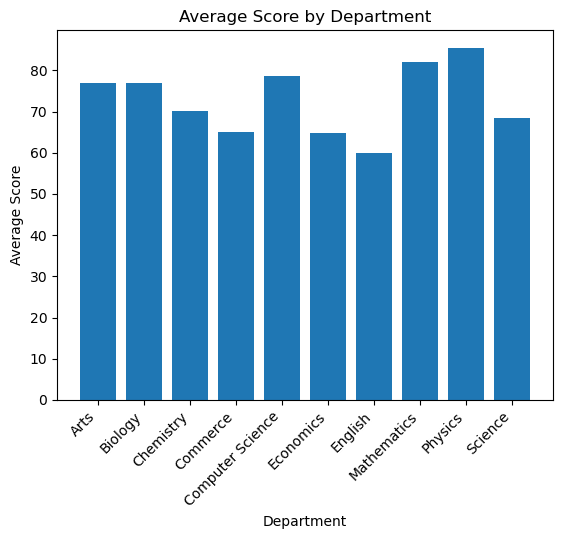

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

avg_score_per_dept = df.groupby('department')['score'].mean()

plt.xlabel("Department")
plt.ylabel("Average Score")
plt.title("Average Score by Department")

plt.bar(avg_score_per_dept.index, avg_score_per_dept.values)

plt.xticks(rotation=45, ha='right')

plt.show()

# Question 06: [ Marks 10 ]

Using Matplotlib, create a histogram of the score column.

* Use 10 bins
* Add a title: "Distribution of Student Scores"
* Label X-axis as "Score" and Y-axis as "Number of Students"
* Display the chart

## Answer 06:

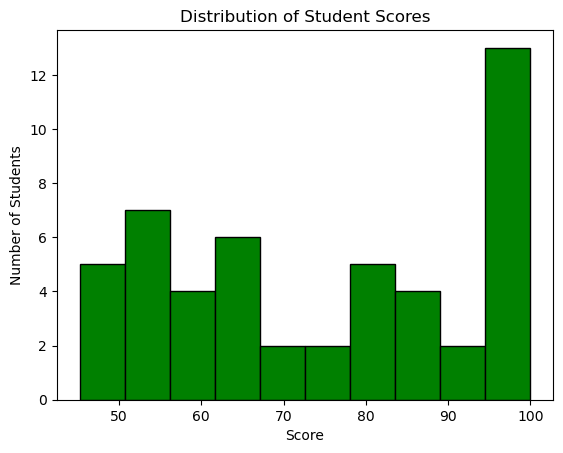

In [11]:
plt.hist(df['score'], bins=10, edgecolor='black', color='green')

plt.title("Distribution of Student Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")

plt.show()

# Question 07: [ Marks 10 ]

Using Matplotlib, create a scatter plot to visualize the relationship between attendance and score.

* X-axis: Attendance (%)
* Y-axis: Score
* Add a title: "Attendance vs Score"
* Label both axes properly
* Display the chart

## Answer 07:


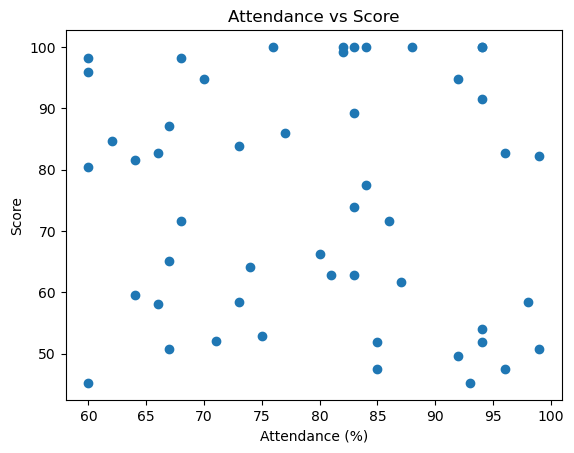

In [13]:
plt.scatter(df['attendance'], df['score'])

plt.title("Attendance vs Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Score")

plt.show()

# Question 08: [ Marks 10 ]

Using Seaborn, create a boxplot / barplot that shows the distribution of score across different grade categories.

* X-axis: Grade
* Y-axis: Score
* Add a title: "Score Distribution by Grade"
* Display the chart

## Answer 08:

Text(0.5, 1.0, 'Score Distribution by Grade')

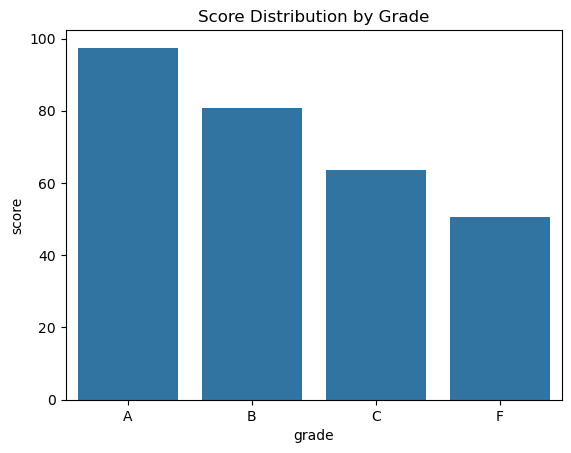

In [14]:
import seaborn as sns

sns.barplot(data=df, x='grade', y='score', errorbar=None, order=['A', 'B', 'C', 'F'])

plt.title("Score Distribution by Grade")

# Question 09: [ Marks 10 ]

Using Seaborn, create a countplot showing the number of students in each department.

* Add a title: "Number of Students per Department"
* Display the chart

## Write Answer 09:

Text(0.5, 1.0, 'Number of Students per Department')

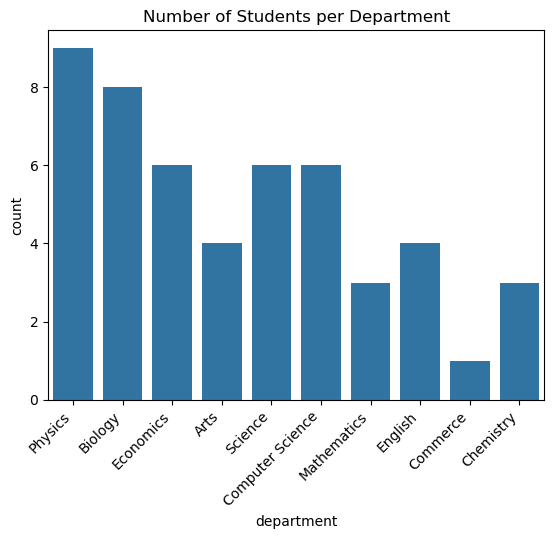

In [15]:
sns.countplot(data=df, x='department')

plt.xticks(rotation=45, ha='right')

plt.title("Number of Students per Department")

# Question 10: [ Marks 10 ]

create a scatter plot showing attendance vs score.

* Color the points by department
* Add a title: "Attendance vs Score by Department"
* Label X-axis as "Attendance (%)" and Y-axis as "Score"
* Display the chart

## Write Answer 10:

Text(54.117309027777765, 0.5, 'Score')

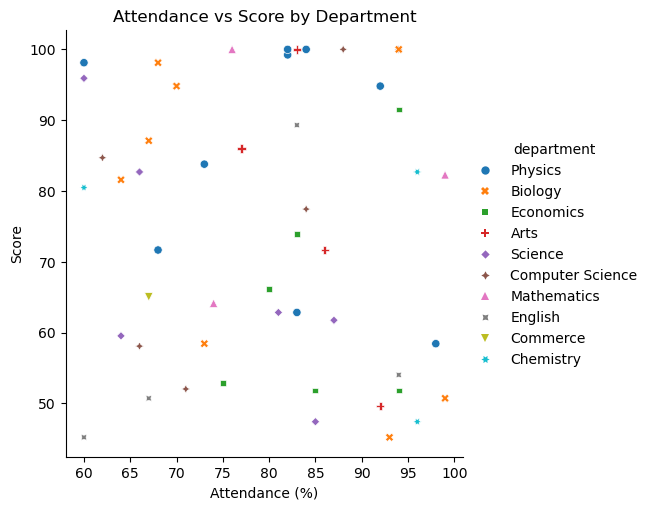

In [16]:
sns.relplot(kind='scatter', data=df, x='attendance', y='score', hue='department', style='department')

plt.title("Attendance vs Score by Department")
plt.xlabel("Attendance (%)")
plt.ylabel("Score")
#